# Stats and visuals for the public spine

In [48]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot
import upsetplot


In [49]:
basefilename = '/Users/fionack/Projects/TSO_project/public_spine_data/public_spine'
#basefilename = '/Users/fionack/Projects/TSO_project/tso-database-builder/main_spine.ccew.oscr.ccni.ch.csv'#main_spine.ccew.oscr'
spine_df = pd.read_csv(basefilename+'.spine.csv',usecols=['uid','normalisedname'])
extras_df = pd.read_csv(basefilename+'.supplementary.csv',usecols=['uid','normalisedname','source'])
matches_df = pd.read_csv(basefilename+'.matches.csv')

print(f'There are {spine_df.shape[0]} rows in the main spine, {extras_df.shape[0]} rows of supplementary data and {matches_df.shape[0]} matches found.\n')

There are 777377 rows in the main spine, 1131632 rows of supplementary data and 104808 matches found.



/var/folders/kx/my6qjd410pg_mks04z_5dm3r0000gn/T/ipykernel_25956/980172203.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  matches_df = pd.read_csv(basefilename+'.matches.csv')


## Counts per source in main spine

basesource
COH     354443
CHC     337826
SC       49306
MPR      18649
COOP      9239
NIC       7746
SHR        158
SHPE        10
Name: count, dtype: int64


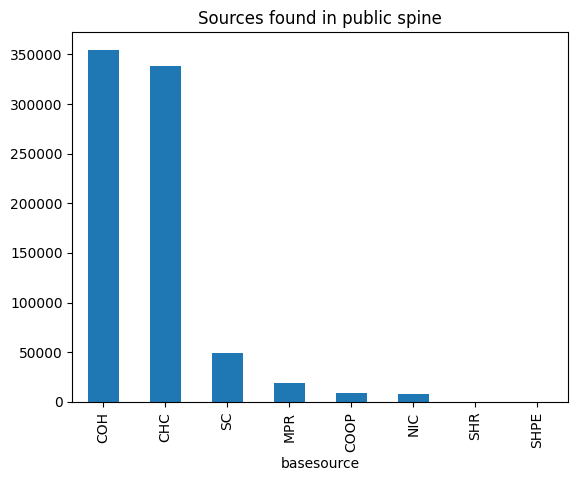

In [50]:
spine_df['basesource'] = spine_df.apply(lambda row: row['uid'].split('-')[1], axis=1)

source_counts = spine_df['basesource'].value_counts(dropna=False)
source_counts = source_counts.rename(index={np.nan: 'NaN'})
print(source_counts)
source_counts.plot(kind='bar')
pyplot.title('Sources found in public spine')
pyplot.savefig('%s.sources.png'%basefilename)


Text(0.5, 1.0, 'Sources found in supplementary data')

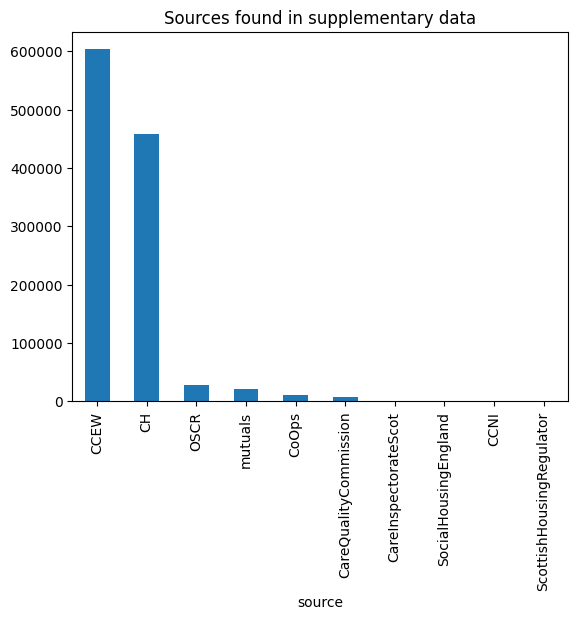

In [51]:

source_counts = extras_df['source'].value_counts(dropna=False)
source_counts = source_counts.rename(index={np.nan: 'NaN'})
source_counts.plot(kind='bar')
pyplot.title('Sources found in supplementary data')


                    uid
0       GB-COH-07772964
1       GB-COH-11266550
2         GB-NIC-106235
3         GB-MPR-2698RS
4        GB-CHC-1034188
...                 ...
873059  GB-COH-04620457
873060  GB-COH-IP27503R
873061   GB-CHC-1086001
873062   GB-CHC-1129066
873063   GB-CHC-1034340

[873064 rows x 1 columns]
basesource
COH     428276
CHC     341870
SC       50566
MPR      31673
COOP     10562
NIC       7746
CQC        970
SHPE       712
CIS        531
SHR        158
Name: count, dtype: int64


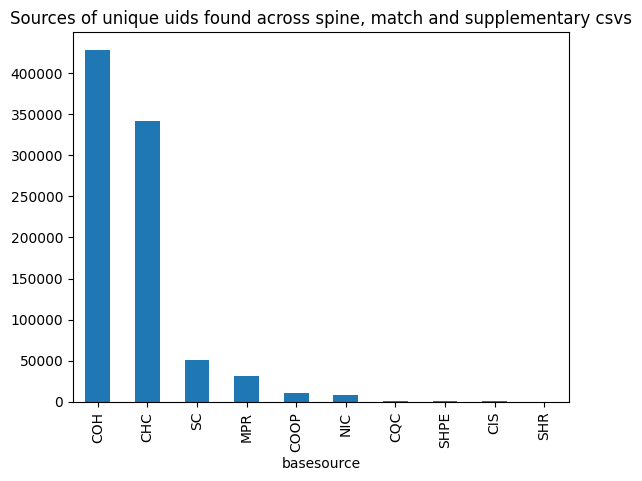

In [52]:
# find all uids used across all data:
uid_set = set(list(spine_df['uid']) + list(matches_df['orgA_uid']) + list(matches_df['orgB_uid']) + list(extras_df['uid']))

all_df = pd.DataFrame(uid_set,columns=['uid'])
print(all_df)
all_df['basesource'] = all_df.apply(lambda row: row['uid'].split('-')[1], axis=1)

source_counts = all_df['basesource'].value_counts(dropna=False)
source_counts = source_counts.rename(index={np.nan: 'NaN'})
print(source_counts)
source_counts.plot(kind='bar')


pyplot.title('Sources of unique uids found across spine, match and supplementary csvs')

pyplot.savefig('%s.all.sources.png'%basefilename)


source_counts = [f"{source} & {count} \\\\ \\hline\n" for source, count in source_counts.items()]

with open(basefilename+'.all_used_orgs.tab.tex', 'w') as ofile:

    ofile.write('\\begin{table}[h]\n  \\centering\n')
    ofile.write('\\begin{tabular}{|l|r|}\n    \\hline\n')
    ofile.write('Source & Count of orgs \\\\ \\hline \\hline\n')

    for i in source_counts:
        ofile.write(i)

    ofile.write('\\end{tabular}\n')
    ofile.write('\\caption{Count of organisations per source}\n')
    ofile.write('\\label{tab:all_used_orgs}\n')
    ofile.write('\\end{table}\n')



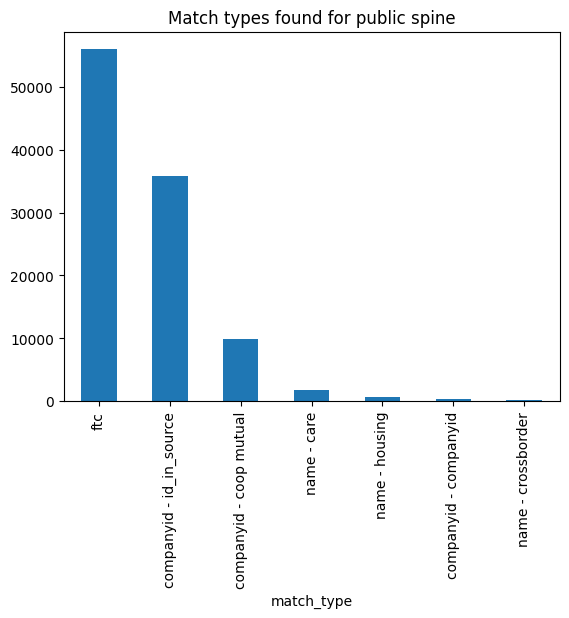

In [75]:

match_types = matches_df['match_type'].value_counts(dropna=False)
match_types = match_types.rename(index={np.nan: 'NaN'})
match_types.plot(kind='bar')
pyplot.title('Match types found for public spine')

pyplot.savefig('%s.matchtypes.png'%basefilename)
pyplot.show()
# also think of how to plot this so that identical matches are shown in a different way - pairs of organisations which are matched by ftc and also name, for example - this chart doesn't differentiate



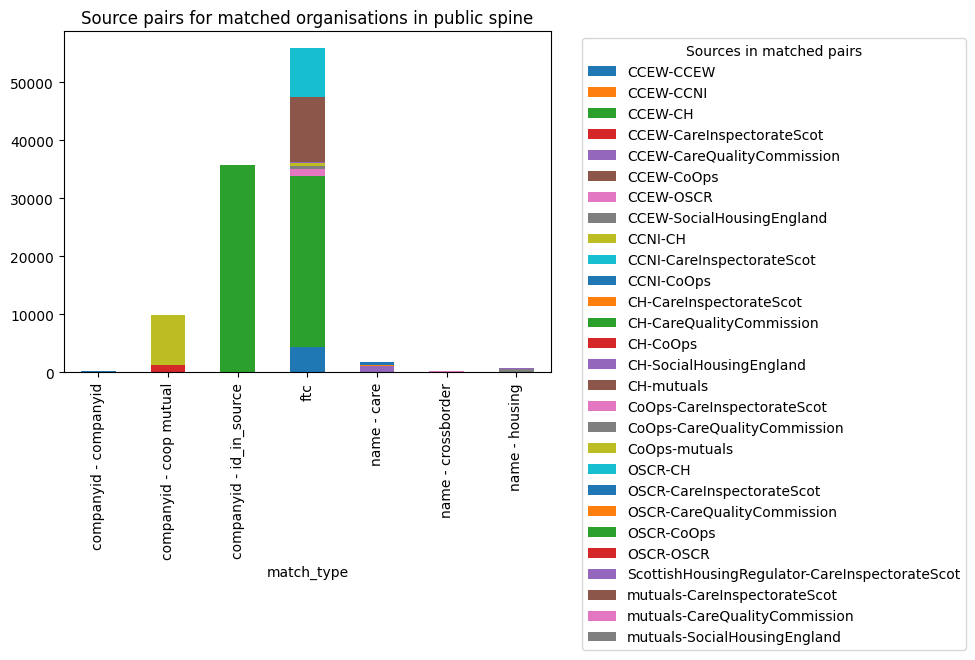

<Figure size 640x480 with 0 Axes>

In [54]:
matches_df['source-source'] = matches_df.apply(lambda row: '%s-%s'%(row['orgA_source'],row['orgB_source']), axis=1)
match_types = matches_df.groupby('match_type')['source-source'].value_counts(dropna=False)
match_types = match_types.rename(index={np.nan: 'NaN'})

# Convert Series to DataFrame for plotting
match_types = match_types.unstack().fillna(0)

# Plot the data
match_types.plot(kind='bar', stacked=True, figsize=(10, 6))
pyplot.title('Source pairs for matched organisations in public spine')
pyplot.legend(title='Sources in matched pairs', bbox_to_anchor=(1.05, 1), loc='upper left')

pyplot.tight_layout()
pyplot.show()
pyplot.savefig('%s.match_source_pairs.types.png'%basefilename)

In [55]:
def plot_upset_matches(infile):
     #print(type(source_list))
    df = pd.read_csv(infile,usecols=['orgA_source','orgB_source'])
    source_order = {'CCEW': 1, 
                    'OSCR' : 2,
                    'CCNI': 3, 
                    'CH' : 4,
                    'CoOps' : 5,
                    'mutuals' : 6,
                    'ScottishHousingRegulator' : 7,
                    'SocialHousingEngland' : 8,
                    'CareInspectorateScot' : 9,
                    'CareQualityCommission' : 10
                    }

    for s in source_order.keys():
    
        df[s] = (matches_df['orgA_source'] == s) | (matches_df['orgB_source'] == s)
        # now df has a column for each source type, indicating whether uid is from source or not
    
    df.drop(labels=['orgA_source','orgB_source'],axis=1, inplace=True)
    source_list = df.columns.tolist()
    # Group by source_list and get the size
    df_grouped = df.groupby(source_list).size()
    
    upsetplot.plot(df_grouped, orientation='horizontal')#, sort_by=source_order)

    pyplot.title("Matches between data sources found in %s"%os.path.basename(infile))
    pyplot.savefig('%s.upsetplot.png'%infile)
    pyplot.show()


/Users/fionack/Projects/TSO_project/tso-database-builder/.tso/lib/python3.11/site-packages/upsetplot/plotting.py:662: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['#0000002e' 'black' '#0000002e' '#0000002e' '#0000002e' '#0000002e'
 '#0000002e' '#0000002e' '#0000002e' '#0000002e' '#0000002e' '#0000002e'
 '#0000002e' 'black' '#0000002e' '#0000002e' '#0000002e' '#0000002e'
 '#0000002e' '#0000002e' 'black' 'black' '#0000002e' '#0000002e'
 '#0000002e' '#0000002e' '#0000002e' '#0000002e' '#0000002e' '#0000002e'
 'black' '#0000002e' 'black' '#0000002e' '#0000002e' '#0000002e'
 '#0000002e' '#0000002e' '#0000002e' '#0000002e' 'black' '#0000002e'
 '#0000002e' 'black' '#0000002e' '#0000002e' '#0000002e' '#0000002e'
 '#0000002e' '#0000002e' '#0000002e' 'black' '#0000002e' 'black'
 '#0000002e' '#0000002e' '#0000002e' '#0000002e' '#0000002e' '#0000002e'
 'black' '#0000002e' '#0000002e' '#0000002e' 'black' '#0000002e'
 '#000000

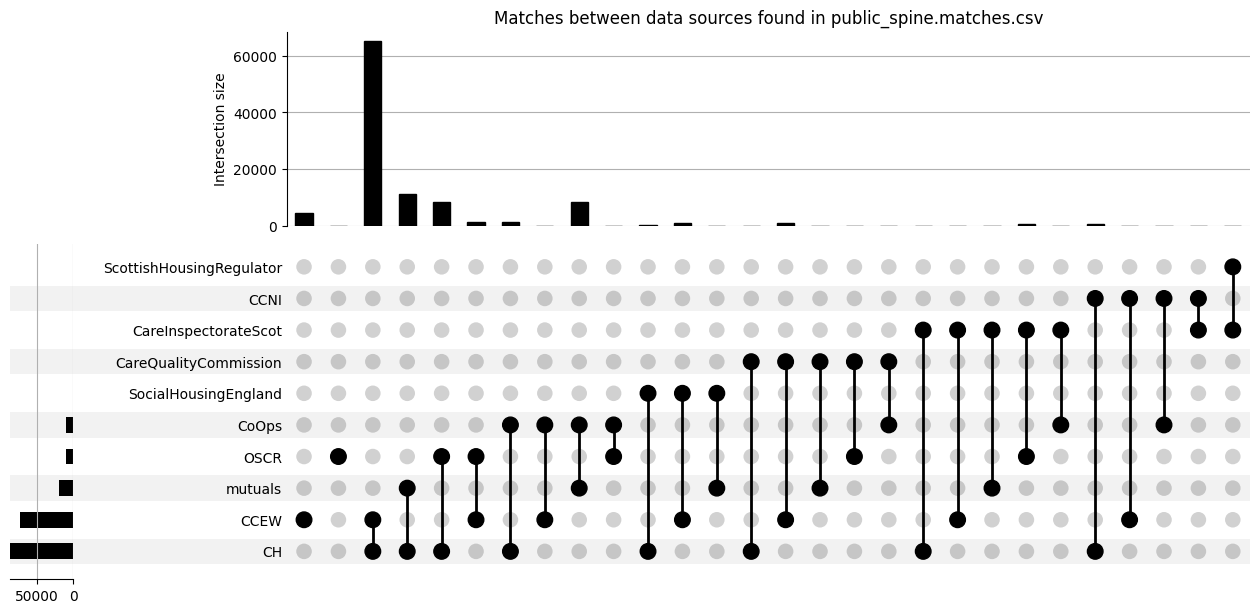

In [56]:
plot_upset_matches(basefilename+'.matches.csv')

In [57]:

sources = np.union1d(matches_df['orgB_source'].unique(), matches_df['orgA_source'].unique())

print(sources)

['CCEW' 'CCNI' 'CH' 'CareInspectorateScot' 'CareQualityCommission' 'CoOps'
 'OSCR' 'ScottishHousingRegulator' 'SocialHousingEngland' 'mutuals']


In [67]:
uids_in_matches_df = set(matches_df['orgA_uid'] + matches_df['orgB_uid'])
print(f'Unique uids in matches csv = {len(uids_in_matches_df)}')
print(f"Unique uids in main spine csv = {len(set(spine_df['uid']))}")

orga_uids = set(matches_df['orgA_uid'])
orgb_uids = set(matches_df['orgB_uid'])

print(f'Organisations found in positions OrgA and OrgB in matches.csv: {orga_uids.intersection(orgb_uids)}')
print(f'Number of unique organisations in position OrgA = {len(orga_uids)}, and unique OrgB uids = {len(orgb_uids)}')

Unique uids in matches csv = 104060
Unique uids in main spine csv = 777377
Organisations found in positions OrgA and OrgB in matches.csv: set()
Number of unique organisations in position OrgA = 99793, and unique OrgB uids = 95999


In [59]:
match_types

source-source,CCEW-CCEW,CCEW-CCNI,CCEW-CH,CCEW-CareInspectorateScot,CCEW-CareQualityCommission,CCEW-CoOps,CCEW-OSCR,CCEW-SocialHousingEngland,CCNI-CH,CCNI-CareInspectorateScot,...,CoOps-mutuals,OSCR-CH,OSCR-CareInspectorateScot,OSCR-CareQualityCommission,OSCR-CoOps,OSCR-OSCR,ScottishHousingRegulator-CareInspectorateScot,mutuals-CareInspectorateScot,mutuals-CareQualityCommission,mutuals-SocialHousingEngland
match_type,,,,,,,,,,,,,,,,,,,,,
companyid - companyid,269.0,1.0,0.0,0.0,0.0,42.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
companyid - coop mutual,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8609.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
companyid - id_in_source,0.0,0.0,35836.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ftc,4452.0,0.0,29341.0,0.0,0.0,0.0,1239.0,473.0,655.0,0.0,...,0.0,8497.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
name - care,0.0,0.0,0.0,22.0,1066.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,552.0,4.0,0.0,0.0,15.0,3.0,1.0,0.0
name - crossborder,0.0,0.0,0.0,0.0,0.0,0.0,233.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
name - housing,0.0,0.0,0.0,0.0,0.0,0.0,0.0,569.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0


Find the numbers of matches found by any combination of match types:

In [73]:
match_types_dict = {}  #
uid_uid_match_dict = {}
print(matches_df)                   
matches_df['uid-uid'] = matches_df.apply(lambda row: '%s:%s' % tuple(sorted([row['orgA_uid'], row['orgB_uid']])), axis=1)
#print(matches_df)
#
unique_uidA_uidB = set(matches_df['uid-uid'])
#print(unique_uidA_uidB)
print(f'Number of uniquely matched pairs of orgs in matches csv = {len(unique_uidA_uidB)} (of {matches_df.shape[0]} rows in matches csv)')
matches_df['uid-uid'].value_counts()

matches_df[matches_df['uid-uid']=='GB-CHC-1015943:GB-SHPE-A4196']

                  uid orgA_id_in_source               orgA_source  \
0       GB-CHC-200002            200002                      CCEW   
1       GB-CHC-200009            200009                      CCEW   
2       GB-CHC-200024            200024                      CCEW   
3       GB-CHC-200027            200027                      CCEW   
4       GB-CHC-200048            200048                      CCEW   
...               ...               ...                       ...   
104803     GB-SHR-173               173  ScottishHousingRegulator   
104804     GB-SHR-180               180  ScottishHousingRegulator   
104805     GB-SHR-197               197  ScottishHousingRegulator   
104806     GB-SHR-143               143  ScottishHousingRegulator   
104807     GB-SHR-199               199  ScottishHousingRegulator   

             orgA_uid orgB_id_in_source           orgB_source  \
0       GB-CHC-200002           1193337                  CCEW   
1       GB-CHC-200009          00686799  

,uid,orgA_id_in_source,orgA_source,orgA_uid,orgB_id_in_source,orgB_source,orgB_uid,match_type,source-source,uid-uid
10670,GB-CHC-1015943,1015943,CCEW,GB-CHC-1015943,A4196,SocialHousingEngland,GB-SHPE-A4196,ftc,CCEW-SocialHousingEngland,GB-CHC-1015943:GB-SHPE-A4196
10671,GB-CHC-1015943,1015943,CCEW,GB-CHC-1015943,A4196,SocialHousingEngland,GB-SHPE-A4196,name - housing,CCEW-SocialHousingEngland,GB-CHC-1015943:GB-SHPE-A4196


In [ ]:
uid_uid_match_dict

In [62]:
matches_df

,uid,orgA_id_in_source,orgA_source,orgA_uid,orgB_id_in_source,orgB_source,orgB_uid,match_type,source-source,uid-uid
0,GB-CHC-200002,200002,CCEW,GB-CHC-200002,1193337,CCEW,GB-CHC-1193337,ftc,CCEW-CCEW,GB-CHC-1193337:GB-CHC-200002
1,GB-CHC-200009,200009,CCEW,GB-CHC-200009,00686799,CH,GB-COH-00686799,companyid - id_in_source,CCEW-CH,GB-CHC-200009:GB-COH-00686799
2,GB-CHC-200024,200024,CCEW,GB-CHC-200024,00682766,CH,GB-COH-00682766,companyid - id_in_source,CCEW-CH,GB-CHC-200024:GB-COH-00682766
3,GB-CHC-200027,200027,CCEW,GB-CHC-200027,00688281,CH,GB-COH-00688281,companyid - id_in_source,CCEW-CH,GB-CHC-200027:GB-COH-00688281
4,GB-CHC-200048,200048,CCEW,GB-CHC-200048,00683275,CH,GB-COH-00683275,companyid - id_in_source,CCEW-CH,GB-CHC-200048:GB-COH-00683275
...,...,...,...,...,...,...,...,...,...,...
104803,GB-SHR-173,173,ScottishHousingRegulator,GB-SHR-173,CS2003054041,CareInspectorateScot,GB-CIS-CS2003054041,name - care,ScottishHousingRegulator-CareInspectorateScot,GB-CIS-CS2003054041:GB-SHR-173
104804,GB-SHR-180,180,ScottishHousingRegulator,GB-SHR-180,CS2004059557,CareInspectorateScot,GB-CIS-CS2004059557,name - care,ScottishHousingRegulator-CareInspectorateScot,GB-CIS-CS2004059557:GB-SHR-180
104805,GB-SHR-197,197,ScottishHousingRegulator,GB-SHR-197,CS2003055549,CareInspectorateScot,GB-CIS-CS2003055549,name - care,ScottishHousingRegulator-CareInspectorateScot,GB-CIS-CS2003055549:GB-SHR-197
104806,GB-SHR-143,143,ScottishHousingRegulator,GB-SHR-143,CS2004056339,CareInspectorateScot,GB-CIS-CS2004056339,name - care,ScottishHousingRegulator-CareInspectorateScot,GB-CIS-CS2004056339:GB-SHR-143


In [63]:

oscr_oscr_matches = matches_df[(matches_df['orgA_source'] == 'OSCR') & (matches_df['orgB_source'] == 'OSCR')]


In [64]:
oscr_oscr_matches

,uid,orgA_id_in_source,orgA_source,orgA_uid,orgB_id_in_source,orgB_source,orgB_uid,match_type,source-source,uid-uid
81150,GB-SC-SC050464,SC050464,OSCR,GB-SC-SC050464,SC051056,OSCR,GB-SC-SC051056,name - crossborder,OSCR-OSCR,GB-SC-SC050464:GB-SC-SC051056


In [65]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'